In [1]:
import pandas as pd
from scipy.stats import pearsonr
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt 

### Figure 4A

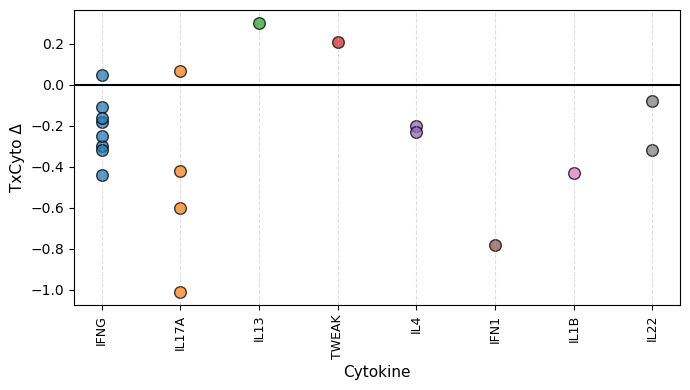

In [2]:
#TxCyto_CytoSig_compare_delta_df=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/Txcyto_zscored_cytosig_delta.csv",index_col='Unnamed: 0')
TxCyto_CytoSig_compare_delta_df=pd.read_csv("/data/kumarr17/TxCyto/results/Txcyto_zscored_cytosig_delta.csv",index_col='Unnamed: 0')

df=TxCyto_CytoSig_compare_delta_df
fig, ax = plt.subplots(figsize=(7, 4))

# Unique cytokines
cytokines = df["cytokine"].unique()

colors = plt.cm.tab10(range(len(cytokines)))
color_map = dict(zip(cytokines, colors))

for cyt in cytokines:
    sub = df[df["cytokine"] == cyt]

    ax.scatter(
        [cyt] * len(sub),
        sub["TxCyto_delta"],
        s=70,
        color=color_map[cyt],
        edgecolor="black",
        linewidth=1,
        alpha=0.75
    )

# Reference line at zero
ax.axhline(
    0,
    color="black",
    linewidth=1.5
)

ax.set_ylabel("TxCyto Δ", fontsize=11)
ax.set_xlabel("Cytokine",fontsize=11)

ax.tick_params(
    axis="x",
    rotation=90,
    labelsize=9
)

ax.tick_params(
    axis="y",
    labelsize=10
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)
plt.tight_layout()

# Save as vector SVG
#plt.savefig(
#    "/data/kumarr17/figures_to_upload/Figure3/TxCyto_delta_by_cytokine.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()

### Figure 4C

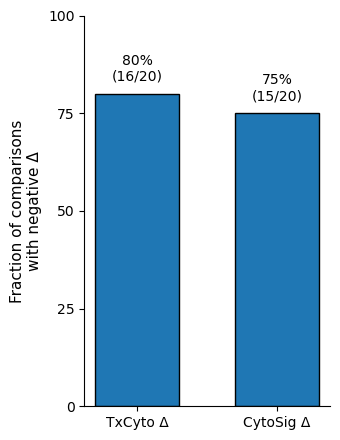

In [3]:
# Accuracy values
methods = ["TxCyto Δ", "CytoSig Δ"]
accuracy = [16/20, 15/20]
counts = [16, 15]
total = 20

# Create figure
fig, ax = plt.subplots(figsize=(3.5, 4.5))

bars = ax.bar(
    methods,
    accuracy,
    width=0.6,
    edgecolor="black",
    linewidth=1
)

# Add percentage and counts above bars
for bar, val, count in zip(bars, accuracy, counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.025,
        f"{val:.0%}\n({count}/{total})",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Y-axis
ax.set_ylabel(
    "Fraction of comparisons\nwith negative Δ",
    fontsize=11
)

ax.set_ylim(0, 1.0)

# Show percentages on y-axis
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(["0", "25", "50", "75", "100"])

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

ax.grid(False)

# Remove unnecessary top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save as vector SVG
#plt.savefig(
#    "/data/kumarr17/figures_to_upload/Figure3/TxCyto_CytoSig_directional_accuracy.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()

In [4]:
final_df=df
# Assign direction based on sign
final_df["TxCyto_direction"] = np.where(
    final_df["TxCyto_delta"] > 0,
    "Increase",
    "Decrease"
)

final_df["CytoSig_direction"] = np.where(
    final_df["CytoSig_delta"] > 0,
    "Increase",
    "Decrease"
)

# Create truth table
truth_table = pd.crosstab(
    final_df["TxCyto_direction"],
    final_df["CytoSig_direction"]
)

# Ensure both categories appear even when count is zero
truth_table = truth_table.reindex(
    index=["Decrease", "Increase"],
    columns=["Decrease", "Increase"],
    fill_value=0
)

truth_table.index.name = "TxCyto"
truth_table.columns.name = "CytoSig"

print(truth_table)

CytoSig   Decrease  Increase
TxCyto                      
Decrease        11         5
Increase         4         0


### Figure 4B

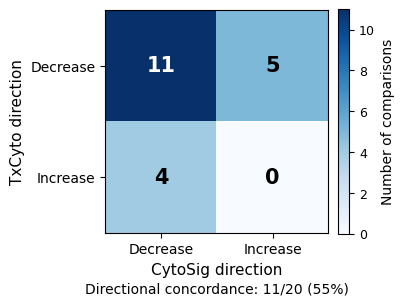

In [5]:
fig, ax = plt.subplots(figsize=(4, 3.5))

# Plot directional concordance matrix
im = ax.imshow(
    truth_table.values,
    cmap="Blues"
)

# Axis labels
ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["Decrease", "Increase"],
    fontsize=10
)

ax.set_yticks([0, 1])
ax.set_yticklabels(
    ["Decrease", "Increase"],
    fontsize=10
)

ax.set_xlabel("CytoSig direction", fontsize=11)
ax.set_ylabel("TxCyto direction", fontsize=11)

# Add counts inside cells
threshold = truth_table.values.max() / 2

for i in range(truth_table.shape[0]):
    for j in range(truth_table.shape[1]):

        value = truth_table.iloc[i, j]

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=15,
            fontweight="bold",
            color="white" if value > threshold else "black"
        )

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Number of comparisons",
    fontsize=10
)

cbar.ax.tick_params(labelsize=9)

#  annotation
ax.text(
    0.5,
    -0.22,
    "Directional concordance: 11/20 (55%)",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10
)

plt.tight_layout()

# Save figure as vector SVG
#plt.savefig(
#    "/data/kumarr17/figures_to_upload/Figure3/TxCyto_CytoSig_directional_concordance.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()